# Model Training
This notebook trains and compares two sentiment classification models using the cleaned Touch 'n Go review dataset.

In [1]:
!pip install pandas scikit-learn joblib matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
CLEANED_DATA_PATH = "../data/cleaned_data.csv"
MODEL_DIR = "../models"
RESULT_DIR = "../results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

Load cleaned dataset

In [4]:
df = pd.read_csv(CLEANED_DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (18835, 10)


,review_id,review_text,rating,thumbs_up_count,review_datetime,sentiment_label,cleaned_review,raw_review_length,cleaned_review_length,cleaned_word_count
0,7bdb015a-5670-4177-8379-b7a2f5f7a35b,new update really troublesome! remove the impo...,1,0,2026-06-29 21:45:10,negative,new update really troublesome remove important...,119,87,12
1,995f7b18-1ded-443e-bc8f-6592f7f8bd81,good,5,0,2026-06-29 21:23:25,positive,good,4,4,1
2,8b79bed1-74c9-42e2-8749-b682baecd60b,One of the most horrible UI design I've ever e...,1,0,2026-06-29 20:49:33,negative,one horrible design ever encountered designer ...,97,52,7
3,5c58b099-e276-4769-937d-9bb3efcd00b8,Bloatware. UI front page now focused on sellin...,1,0,2026-06-29 19:03:11,negative,bloatware front page focused selling product b...,212,167,24
4,cb9db6de-88d9-4b19-8999-646665ee8e99,"After update, changing of the UI is still fine...",1,0,2026-06-29 17:22:46,negative,update changing still fine via duit slow need ...,235,141,22


In [5]:
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

print("\nSentiment distribution:")
print(df["sentiment_label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   review_id              18835 non-null  object
 1   review_text            18835 non-null  object
 2   rating                 18835 non-null  int64 
 3   thumbs_up_count        18835 non-null  int64 
 4   review_datetime        18835 non-null  object
 5   sentiment_label        18835 non-null  object
 6   cleaned_review         18835 non-null  object
 7   raw_review_length      18835 non-null  int64 
 8   cleaned_review_length  18835 non-null  int64 
 9   cleaned_word_count     18835 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 1.4+ MB
None

Missing values:
review_id                0
review_text              0
rating                   0
thumbs_up_count          0
review_datetime          0
sentiment_label          0
cleaned_review           0
raw_review_length 

Prepare features and target

In [6]:
df = df.dropna(subset=["cleaned_review", "sentiment_label"]).copy()

X = df["cleaned_review"].astype(str)
y = df["sentiment_label"].astype(str)

print("Total records:", len(X))
print(y.value_counts())

Total records: 18835
sentiment_label
positive    12933
negative     5173
neutral       729
Name: count, dtype: int64


Train-validation-test split
The split ratio is 70% training, 10% validation, and 20% testing.

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=42,
    stratify=y_temp
)

print("Training size:", len(X_train))
print("Validation size:", len(X_val))
print("Testing size:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training size: 13184
Validation size: 1883
Testing size: 3768

Training distribution:
sentiment_label
positive    9053
negative    3621
neutral      510
Name: count, dtype: int64

Validation distribution:
sentiment_label
positive    1293
negative     517
neutral       73
Name: count, dtype: int64

Testing distribution:
sentiment_label
positive    2587
negative    1035
neutral      146
Name: count, dtype: int64


TF-IDF vectorization

In [8]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    lowercase=False
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (13184, 8000)
TF-IDF validation shape: (1883, 8000)
TF-IDF test shape: (3768, 8000)


Train Model 1: Naive Bayes

In [9]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_val_pred = nb_model.predict(X_val_tfidf)

print("Naive Bayes Validation Result")
print(classification_report(y_val, nb_val_pred, zero_division=0))

Naive Bayes Validation Result
              precision    recall  f1-score   support

    negative       0.80      0.92      0.86       517
     neutral       0.00      0.00      0.00        73
    positive       0.95      0.94      0.95      1293

    accuracy                           0.90      1883
   macro avg       0.58      0.62      0.60      1883
weighted avg       0.87      0.90      0.88      1883



Train Model 2: Linear SVM

In [10]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_val_pred = svm_model.predict(X_val_tfidf)

print("SVM Validation Result")
print(classification_report(y_val, svm_val_pred, zero_division=0))

SVM Validation Result
              precision    recall  f1-score   support

    negative       0.81      0.85      0.83       517
     neutral       0.09      0.07      0.08        73
    positive       0.94      0.94      0.94      1293

    accuracy                           0.88      1883
   macro avg       0.61      0.62      0.62      1883
weighted avg       0.87      0.88      0.88      1883



Evaluate models on test data

In [11]:
models = {
    "Naive Bayes": nb_model,
    "SVM": svm_model
}

results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test_tfidf)

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Naive Bayes,0.889331,0.860148,0.889331,0.873478
1,SVM,0.868365,0.861797,0.868365,0.864344


In [12]:
model_comparison_path = os.path.join(RESULT_DIR, "model_comparison.csv")
results_df.to_csv(model_comparison_path, index=False)

print("Model comparison saved to:", model_comparison_path)

Model comparison saved to: ../results\model_comparison.csv


Detailed classification reports

In [13]:
nb_test_pred = nb_model.predict(X_test_tfidf)
svm_test_pred = svm_model.predict(X_test_tfidf)

print("Naive Bayes Test Classification Report")
print(classification_report(y_test, nb_test_pred, zero_division=0))

print("\nSVM Test Classification Report")
print(classification_report(y_test, svm_test_pred, zero_division=0))

Naive Bayes Test Classification Report
              precision    recall  f1-score   support

    negative       0.78      0.90      0.83      1035
     neutral       0.00      0.00      0.00       146
    positive       0.94      0.94      0.94      2587

    accuracy                           0.89      3768
   macro avg       0.57      0.61      0.59      3768
weighted avg       0.86      0.89      0.87      3768


SVM Test Classification Report
              precision    recall  f1-score   support

    negative       0.77      0.84      0.80      1035
     neutral       0.17      0.11      0.13       146
    positive       0.94      0.92      0.93      2587

    accuracy                           0.87      3768
   macro avg       0.63      0.62      0.62      3768
weighted avg       0.86      0.87      0.86      3768



Confusion matrices

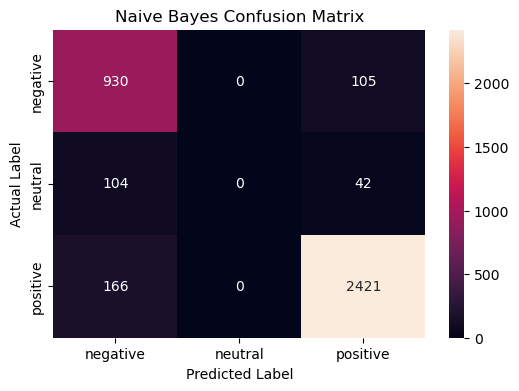

In [14]:
labels = ["negative", "neutral", "positive"]

cm_nb = confusion_matrix(y_test, nb_test_pred, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

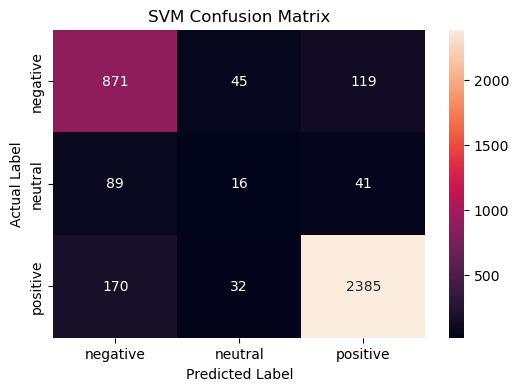

In [15]:
cm_svm = confusion_matrix(y_test, svm_test_pred, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Select best model

In [16]:
best_model_row = results_df.sort_values(by="f1_weighted", ascending=False).iloc[0]
best_model_name = best_model_row["model"]

print("Best model based on weighted F1-score:", best_model_name)
best_model_row

Best model based on weighted F1-score: Naive Bayes


model                 Naive Bayes
accuracy                 0.889331
precision_weighted       0.860148
recall_weighted          0.889331
f1_weighted              0.873478
Name: 0, dtype: object

Save vectorizer and trained models

In [17]:
vectorizer_path = os.path.join(MODEL_DIR, "vectorizer.pkl")
nb_model_path = os.path.join(MODEL_DIR, "naive_bayes_model.pkl")
svm_model_path = os.path.join(MODEL_DIR, "linear_svm_model.pkl")

joblib.dump(vectorizer, vectorizer_path)
joblib.dump(nb_model, nb_model_path)
joblib.dump(svm_model, svm_model_path)

print("Saved:", vectorizer_path)
print("Saved:", nb_model_path)
print("Saved:", svm_model_path)

Saved: ../models\vectorizer.pkl
Saved: ../models\naive_bayes_model.pkl
Saved: ../models\linear_svm_model.pkl


Test model with sample reviews

In [18]:
sample_reviews = [
    "useful easy use",
    "new update slow troublesome",
    "okay sometimes login problem"
]

sample_tfidf = vectorizer.transform(sample_reviews)

print("Naive Bayes predictions:")
print(nb_model.predict(sample_tfidf))

print("\nSVM predictions:")
print(svm_model.predict(sample_tfidf))

Naive Bayes predictions:
['positive' 'negative' 'positive']

SVM predictions:
['positive' 'negative' 'neutral']
